## Rule-Based BESS Arbitrage Backtest on German Hourly Power Prices

**Objective**

This notebook tests whether simple, interpretable battery dispatch strategies can monetize the price structure identified in the market exploration step.


**Goal**: We want to do the following

- Build a minimal battery model
- Run 2 simple arbitrage rules
- Produce cumulative P&L plus operational outputs.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from bess_analytics.data.loader import load_prices

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
pd.set_option("display.max_columns", 50)

### Input data and assumptions

The simulation uses the cleaned hourly German price series from notebook 1 and a simplified battery representation. The assumptions are intentionally transparent so that the performance of each rule can be interpreted without ambiguity.



In [3]:
# Load the dateset and do basic cleaning
df = load_prices("../src/bess_analytics/data/raw/Germany.csv")

if "timestamp_utc" in df.columns:
    df = df.set_index("timestamp_utc").sort_index()

df = df.dropna(subset=["price_eur_mwh"]).copy()

print("Rows:", len(df))
print("Start:", df.index.min())
print("End:", df.index.max())
print("Negative-price hours:", (df["price_eur_mwh"] < 0).sum())

df.head()

/var/folders/3x/jns0_g1d0hz0j981mhlv522h0000gn/T/ipykernel_2841/1070504576.py:2: UserWarning: Source data has 2 missing hour(s). Rows inserted with NaN price.
  df = load_prices("../src/bess_analytics/data/raw/Germany.csv")


Rows: 99932
Start: 2015-01-01 00:00:00+00:00
End: 2026-05-26 21:00:00+00:00
Negative-price hours: 2439


,country,iso3_code,timestamp_local,price_eur_mwh
timestamp_utc,,,,
2015-01-01 00:00:00+00:00,Germany,DEU,2015-01-01 01:00:00,22.34
2015-01-01 01:00:00+00:00,Germany,DEU,2015-01-01 02:00:00,22.34
2015-01-01 02:00:00+00:00,Germany,DEU,2015-01-01 03:00:00,22.34
2015-01-01 03:00:00+00:00,Germany,DEU,2015-01-01 04:00:00,22.34
2015-01-01 04:00:00+00:00,Germany,DEU,2015-01-01 05:00:00,22.34


### Battery assumptions

In [ ]:

BATTERY = {
    "energy_capacity_mwh": 2.0,
    "power_capacity_mw": 1.0,
    "soc_min_mwh": 0.2,
    "soc_max_mwh": 2.0,
    "soc_init_mwh": 1.0,
    "round_trip_efficiency": 0.90,
    "dt_hours": 1.0,
}

BATTERY["charge_efficiency"] = BATTERY["round_trip_efficiency"] ** 0.5
BATTERY["discharge_efficiency"] = BATTERY["round_trip_efficiency"] ** 0.5

pd.Series(BATTERY)

energy_capacity_mwh      2.000000
power_capacity_mw        1.000000
soc_min_mwh              0.200000
soc_max_mwh              2.000000
soc_init_mwh             1.000000
round_trip_efficiency    0.900000
dt_hours                 1.000000
charge_efficiency        0.948683
discharge_efficiency     0.948683
dtype: float64

## Battery specification

The battery is modeled with:
- Energy capacity
- Power capacity
- Minimum and maximum state of charge
- Initial state of charge
- Round-trip efficiency

These constraints determine how much energy can actually be shifted across time and therefore directly affect arbitrage profitability.

### Battery step function

In [6]:
def battery_step(soc_mwh, action_mw, price, cfg):
    dt_hours = cfg["dt_hours"]
    p_max = cfg["power_capacity_mw"]
    soc_min = cfg["soc_min_mwh"]
    soc_max = cfg["soc_max_mwh"]
    eta_c = cfg["charge_efficiency"]
    eta_d = cfg["discharge_efficiency"]

    action_mw = float(np.clip(action_mw, -p_max, p_max))

    charge_from_grid_mwh = 0.0
    discharge_to_grid_mwh = 0.0
    throughput_mwh = 0.0

    if action_mw < 0:
        requested_grid_charge_mwh = abs(action_mw) * dt_hours
        max_grid_charge_mwh = max(0.0, (soc_max - soc_mwh) / eta_c)
        actual_grid_charge_mwh = min(requested_grid_charge_mwh, max_grid_charge_mwh)

        soc_next = soc_mwh + actual_grid_charge_mwh * eta_c
        revenue_eur = -actual_grid_charge_mwh * price
        actual_action_mw = -(actual_grid_charge_mwh / dt_hours)

        charge_from_grid_mwh = actual_grid_charge_mwh
        throughput_mwh = actual_grid_charge_mwh

    elif action_mw > 0:
        requested_grid_discharge_mwh = action_mw * dt_hours
        max_battery_discharge_mwh = max(0.0, soc_mwh - soc_min)
        max_grid_discharge_mwh = max_battery_discharge_mwh * eta_d
        actual_grid_discharge_mwh = min(requested_grid_discharge_mwh, max_grid_discharge_mwh)

        battery_energy_removed_mwh = actual_grid_discharge_mwh / eta_d
        soc_next = soc_mwh - battery_energy_removed_mwh
        revenue_eur = actual_grid_discharge_mwh * price
        actual_action_mw = actual_grid_discharge_mwh / dt_hours

        discharge_to_grid_mwh = actual_grid_discharge_mwh
        throughput_mwh = battery_energy_removed_mwh

    else:
        soc_next = soc_mwh
        revenue_eur = 0.0
        actual_action_mw = 0.0

    soc_next = float(np.clip(soc_next, soc_min, soc_max))

    return {
        "soc_next_mwh": soc_next,
        "revenue_eur": revenue_eur,
        "actual_action_mw": actual_action_mw,
        "charge_from_grid_mwh": charge_from_grid_mwh,
        "discharge_to_grid_mwh": discharge_to_grid_mwh,
        "throughput_mwh": throughput_mwh,
    }

### Strategy thresholds

In [7]:
price_series = df["price_eur_mwh"]

LOW_Q = price_series.quantile(0.25)
HIGH_Q = price_series.quantile(0.75)
VERY_HIGH_Q = price_series.quantile(0.85)

pd.Series(
    {
        "low_threshold_q25": LOW_Q,
        "high_threshold_q75": HIGH_Q,
        "very_high_threshold_q85": VERY_HIGH_Q,
    }
)

low_threshold_q25           30.6900
high_threshold_q75          93.7025
very_high_threshold_q85    121.2035
dtype: float64

In [9]:
def threshold_strategy(price, cfg, low_threshold, high_threshold):
    power_mw = cfg["power_capacity_mw"]

    if price <= low_threshold:
        return -power_mw
    if price >= high_threshold:
        return power_mw
    return 0.0


def negative_price_strategy(price, cfg, high_threshold):
    power_mw = cfg["power_capacity_mw"]

    if price < 0:
        return -power_mw
    if price >= high_threshold:
        return power_mw
    return 0.0

## Strategy definitions

### Strategy A — Threshold arbitrage
Charge when the price is in the lower part of the historical distribution and discharge when it is in the upper part.

### Strategy B — Negative-price-aware arbitrage
Charge whenever prices are negative and discharge during sufficiently high-price periods.

These two rules are deliberately simple and interpretable so their behavior can be explained clearly.

In [10]:
def run_backtest(df, strategy_name, strategy_func, cfg, **strategy_kwargs):
    soc_mwh = cfg["soc_init_mwh"]
    records = []

    for ts, row in df.iterrows():
        price = row["price_eur_mwh"]
        desired_action_mw = strategy_func(price=price, cfg=cfg, **strategy_kwargs)

        step = battery_step(
            soc_mwh=soc_mwh,
            action_mw=desired_action_mw,
            price=price,
            cfg=cfg,
        )

        soc_mwh = step["soc_next_mwh"]

        records.append(
            {
                "timestamp": ts,
                "strategy": strategy_name,
                "price_eur_mwh": price,
                "desired_action_mw": desired_action_mw,
                "action_mw": step["actual_action_mw"],
                "soc_mwh": soc_mwh,
                "revenue_eur": step["revenue_eur"],
                "charge_from_grid_mwh": step["charge_from_grid_mwh"],
                "discharge_to_grid_mwh": step["discharge_to_grid_mwh"],
                "throughput_mwh": step["throughput_mwh"],
                "is_negative_price": price < 0,
            }
        )

    out = pd.DataFrame(records).set_index("timestamp").sort_index()
    out["cum_pnl_eur"] = out["revenue_eur"].cumsum()
    out["hour_of_day"] = out.index.hour
    out["day_of_week"] = out.index.dayofweek
    out["day_name"] = out.index.day_name()
    out["date"] = out.index.date

    return out

In [11]:
bt_threshold = run_backtest(
    df=df,
    strategy_name="threshold",
    strategy_func=threshold_strategy,
    cfg=BATTERY,
    low_threshold=LOW_Q,
    high_threshold=HIGH_Q,
)

bt_negative = run_backtest(
    df=df,
    strategy_name="negative_price",
    strategy_func=negative_price_strategy,
    cfg=BATTERY,
    high_threshold=VERY_HIGH_Q,
)

results = pd.concat([bt_threshold, bt_negative]).sort_index()
results.head()

,strategy,price_eur_mwh,desired_action_mw,action_mw,soc_mwh,revenue_eur,charge_from_grid_mwh,discharge_to_grid_mwh,throughput_mwh,is_negative_price,cum_pnl_eur,hour_of_day,day_of_week,day_name,date
timestamp,,,,,,,,,,,,,,,
2015-01-01 00:00:00+00:00,threshold,22.34,-1.0,-1.000000,1.948683,-22.340000,1.000000,0.0,1.000000,False,-22.340000,0,3,Thursday,2015-01-01
2015-01-01 00:00:00+00:00,negative_price,22.34,0.0,0.000000,1.000000,0.000000,0.000000,0.0,0.000000,False,0.000000,0,3,Thursday,2015-01-01
2015-01-01 01:00:00+00:00,threshold,22.34,-1.0,-0.054093,2.000000,-1.208428,0.054093,0.0,0.054093,False,-23.548428,1,3,Thursday,2015-01-01
2015-01-01 01:00:00+00:00,negative_price,22.34,0.0,0.000000,1.000000,0.000000,0.000000,0.0,0.000000,False,0.000000,1,3,Thursday,2015-01-01
2015-01-01 02:00:00+00:00,threshold,22.34,-1.0,-0.000000,2.000000,-0.000000,0.000000,0.0,0.000000,False,-23.548428,2,3,Thursday,2015-01-01


In [12]:
summary = (
    results.groupby("strategy")
    .agg(
        total_revenue_eur=("revenue_eur", "sum"),
        avg_hourly_revenue_eur=("revenue_eur", "mean"),
        total_charge_mwh=("charge_from_grid_mwh", "sum"),
        total_discharge_mwh=("discharge_to_grid_mwh", "sum"),
        total_throughput_mwh=("throughput_mwh", "sum"),
        avg_soc_mwh=("soc_mwh", "mean"),
    )
    .round(2)
)

summary

,total_revenue_eur,avg_hourly_revenue_eur,total_charge_mwh,total_discharge_mwh,total_throughput_mwh,avg_soc_mwh
strategy,,,,,,
negative_price,45221.01,0.45,346.88,312.95,676.76,1.28
threshold,86498.47,0.87,985.63,887.82,1921.47,1.29


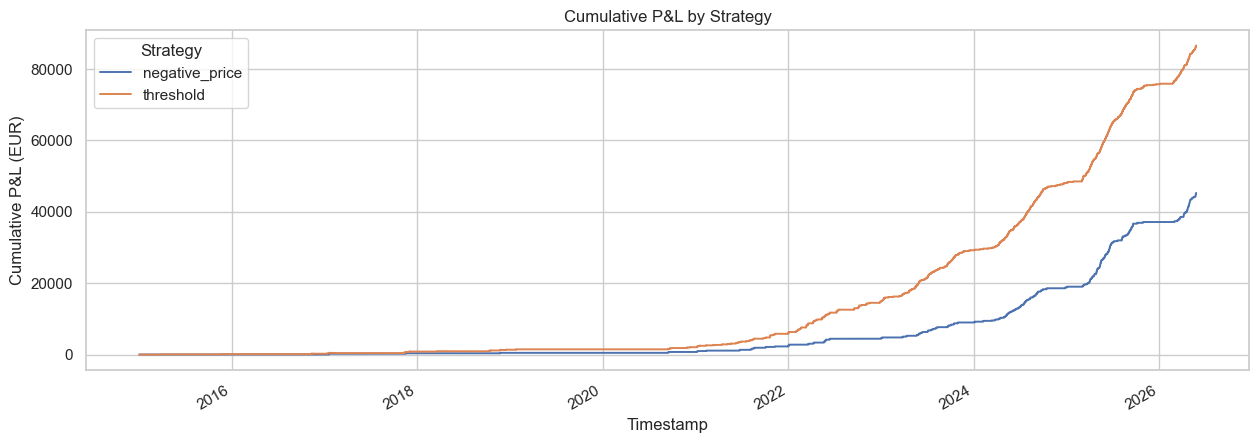

In [13]:
fig, ax = plt.subplots(figsize=(15, 5))

for strategy, temp in results.groupby("strategy"):
    temp["cum_pnl_eur"].plot(ax=ax, label=strategy, linewidth=1.4)

ax.set_title("Cumulative P&L by Strategy")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Cumulative P&L (EUR)")
ax.legend(title="Strategy")
plt.show()

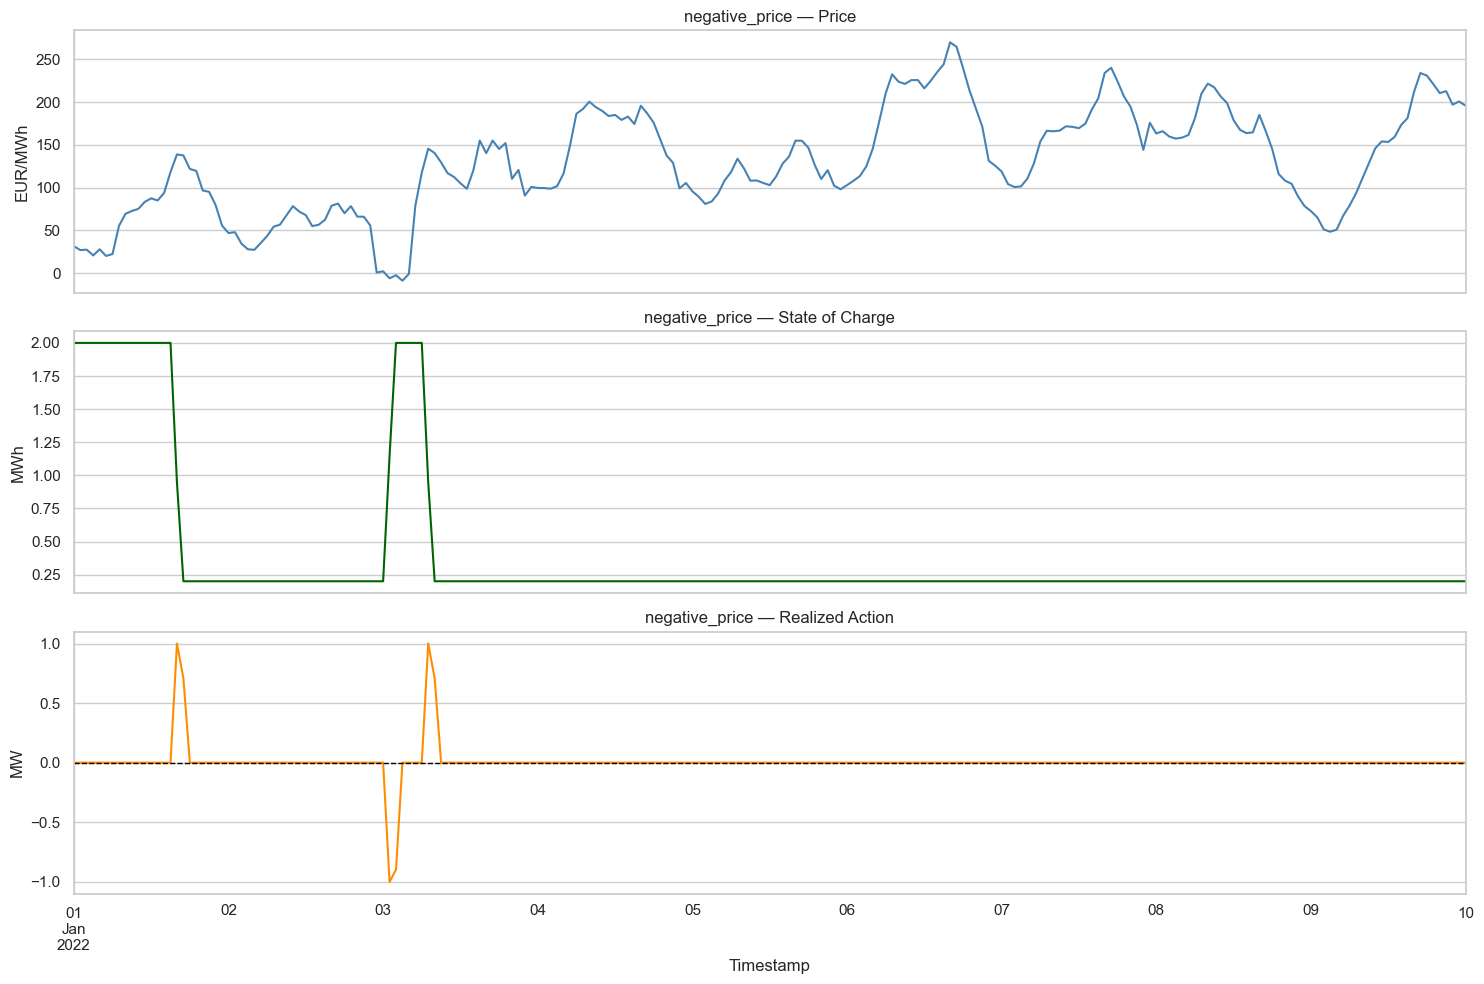

In [14]:
sample_start = "2022-01-01"
sample_end = "2022-01-10"

strategy_to_plot = "negative_price"
sample = results.loc[
    (results.index >= sample_start)
    & (results.index <= sample_end)
    & (results["strategy"] == strategy_to_plot)
].copy()

fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

sample["price_eur_mwh"].plot(ax=axes[0], color="steelblue")
axes[0].set_title(f"{strategy_to_plot} — Price")
axes[0].set_ylabel("EUR/MWh")

sample["soc_mwh"].plot(ax=axes[1], color="darkgreen")
axes[1].set_title(f"{strategy_to_plot} — State of Charge")
axes[1].set_ylabel("MWh")

sample["action_mw"].plot(ax=axes[2], color="darkorange")
axes[2].axhline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_title(f"{strategy_to_plot} — Realized Action")
axes[2].set_ylabel("MW")
axes[2].set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

In [15]:
negative_price_revenue = (
    results.groupby("strategy")
    .apply(lambda x: x.loc[x["is_negative_price"], "revenue_eur"].sum())
    .rename("revenue_during_negative_price_hours_eur")
    .round(2)
)

negative_price_revenue

/var/folders/3x/jns0_g1d0hz0j981mhlv522h0000gn/T/ipykernel_2841/1183893508.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.loc[x["is_negative_price"], "revenue_eur"].sum())


strategy
negative_price    1767.87
threshold          199.26
Name: revenue_during_negative_price_hours_eur, dtype: float64

In [16]:
daily_pnl = (
    results.groupby(["strategy", "date"])["revenue_eur"]
    .sum()
    .reset_index()
    .rename(columns={"revenue_eur": "daily_pnl_eur"})
)

daily_pnl.head()

,strategy,date,daily_pnl_eur
0,negative_price,2015-01-01,0.0
1,negative_price,2015-01-02,0.0
2,negative_price,2015-01-03,0.0
3,negative_price,2015-01-04,0.0
4,negative_price,2015-01-05,0.0


In [17]:
output_dir = Path("output")
output_dir.mkdir(parents=True, exist_ok=True)

bt_threshold.to_csv(output_dir / "bt_threshold.csv")
bt_negative.to_csv(output_dir / "bt_negative.csv")
results.to_csv(output_dir / "backtest_results_all.csv")
daily_pnl.to_csv(output_dir / "daily_pnl.csv", index=False)
summary.to_csv(output_dir / "strategy_summary_preview.csv")

In [ ]:
        qq